### Start by import packages needed

In [27]:
import csv
import os
import random
import sys
import time
from datetime import date
import kaleido
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import requests
from dotenv import load_dotenv

Matplotlib is building the font cache; this may take a moment.


In [ ]:
# Each topic runs until: wall-clock budget, empty results, short page,
# MAX_PAGES_SAFETY, or repeated request failure. Retries for flaky connections.

# Settings
OUTPUT_CSV = "miniproject_dataset.csv"
PER_PAGE = 100
TIMEOUT = 30
# Per search_topic (each string in SEARCH_TOPICS): stop fetching more pages after this
# many wall-clock seconds for that topic only. The next topic gets its own timer.
# This caps total wait when the API returns few "recent" rows per page or errors often.
PER_TOPIC_MAX_SECONDS = 300
MAX_PAGES_SAFETY = 500
# Pause between successful page requests for the same topic. Open Library can drop
# connections (rate limits / load) "connection reset" failures.
SLEEP_BETWEEN_PAGES = 6
# How many times to retry the same page on network errors before giving up.
REQUEST_MAX_RETRIES = 6

# Identify this script as coursework (not anonymous python-requests). Some servers
# treat a missing or generic User-Agent more harshly; a clear string reduce failed or 
# reset connections when scraping public APIs.
HTTP_HEADERS = {
    "User-Agent": "HCDE530-miniproject/1.0 (Open Library; UW coursework)",
}

# "Past year" approximation based on publication year.
CURRENT_YEAR = date.today().year
MIN_YEAR = CURRENT_YEAR - 1

SEARCH_TOPICS = [
    "artificial intelligence",
    "machine learning",
    "deep learning",
    "neural networks",
    "generative AI",
    "large language models",
    "natural language processing",
    "NLP",
    "computer vision",
]

url = "https://openlibrary.org/search.json"

fields = [
    "key",
    "title",
    "author_name",
    "first_publish_year",
    "publish_year",
    "subject",
    "language",
    "edition_count",
    "publisher",
    "place",
]

session = requests.Session()
session.headers.update(HTTP_HEADERS)


def get_search_page(sess, url, params, read_timeout, topic_deadline):
    # Retry loop: same page may fail with ConnectionError/Timeout; backoff sleep gives
    # the server time to recover and avoids hammering it immediately after a reset.
    last_exc = None
    for attempt in range(REQUEST_MAX_RETRIES):
        time_left = topic_deadline - time.monotonic()
        if time_left <= 0:
            return None
        request_timeout = min(read_timeout, max(2.0, time_left))
        try:
            return sess.get(url, params=params, timeout=request_timeout)
        except (
            requests.exceptions.ConnectionError,
            requests.exceptions.Timeout,
            requests.exceptions.ChunkedEncodingError,
        ) as exc:
            last_exc = exc
            backoff = min(45.0, (2**attempt) + random.random() * 1.5)
            time.sleep(backoff)
    print(f"Request failed after {REQUEST_MAX_RETRIES} retries ({last_exc}).")
    return None


all_rows = []
seen_keys = set()

for topic in SEARCH_TOPICS:
    page = 1
    topic_rows_collected = 0
    topic_started = time.monotonic()
    # Absolute end time for this search_topic.
    topic_deadline = topic_started + PER_TOPIC_MAX_SECONDS

    # Fetch pages for this search_topic only until its time budget or safety page cap.
    while (time.monotonic() < topic_deadline) and page <= MAX_PAGES_SAFETY:
        params = {
            "q": topic,
            "fields": ",".join(fields),
            "sort": "new",
            "limit": PER_PAGE,
            "page": page,
        }

        response = get_search_page(session, url, params, TIMEOUT, topic_deadline)
        if response is None:
            print(
                f"No response for topic '{topic}', page {page} "
                f"(retries exhausted or per-topic time budget)."
            )
            break

        if not response.ok:
            print(f"Request failed for topic '{topic}', page {page}")
            print(response.text)
            break

        data = response.json()
        docs = data.get("docs", [])

        if not docs:
            break

        for book in docs:
            if time.monotonic() >= topic_deadline:
                break

            work_key = book.get("key")

            if work_key in seen_keys:
                continue

            seen_keys.add(work_key)

            title = book.get("title")
            authors = book.get("author_name", [])
            first_publish_year = book.get("first_publish_year")
            publish_years = book.get("publish_year", [])
            subjects = book.get("subject", [])
            languages = book.get("language", [])
            publishers = book.get("publisher", [])
            places = book.get("place", [])
            edition_count = book.get("edition_count")

            is_recent = False
            if isinstance(first_publish_year, int) and first_publish_year >= MIN_YEAR:
                is_recent = True
            elif isinstance(publish_years, list):
                recent_years = [
                    y for y in publish_years
                    if isinstance(y, int) and y >= MIN_YEAR
                ]
                if recent_years:
                    is_recent = True

            if not is_recent:
                continue

            row = {
                "search_topic": topic,
                "openlibrary_work_key": work_key,
                "title": title,
                "author_name": "; ".join(authors) if isinstance(authors, list) else authors,
                "first_publish_year": first_publish_year,
                "publish_years": "; ".join(map(str, publish_years)) if isinstance(publish_years, list) else publish_years,
                "subjects": "; ".join(subjects[:25]) if isinstance(subjects, list) else subjects,
                "languages": "; ".join(languages) if isinstance(languages, list) else languages,
                "edition_count": edition_count,
                "publishers": "; ".join(publishers[:10]) if isinstance(publishers, list) else publishers,
                "publication_places": "; ".join(places[:10]) if isinstance(places, list) else places,
            }

            all_rows.append(row)
            topic_rows_collected += 1

        if time.monotonic() >= topic_deadline:
            # Finished processing a page but used the full per-topic time budget for this search_topic.
            print(
                f"Per-topic time budget ({PER_TOPIC_MAX_SECONDS}s) reached for '{topic}'."
            )
            break

        print(
            f"Topic: {topic} | Page: {page} | "
            f"Topic rows: {topic_rows_collected} | Total rows: {len(all_rows)} | "
            f"elapsed {time.monotonic() - topic_started:.0f}s"
        )

        page += 1
        remaining = topic_deadline - time.monotonic()
        if remaining > 0:
            time.sleep(min(SLEEP_BETWEEN_PAGES, remaining))

        if len(docs) < PER_PAGE:
            break

    elapsed = time.monotonic() - topic_started
    if page > MAX_PAGES_SAFETY:
        print(f"Stopped '{topic}' after {MAX_PAGES_SAFETY} pages (safety cap).")
    elif elapsed >= PER_TOPIC_MAX_SECONDS:
        # This search_topic hit its wall-clock cap.
        print(
            f"Stopped '{topic}' after {elapsed:.0f}s (per-topic limit {PER_TOPIC_MAX_SECONDS}s)."
        )
    print(f"Topic '{topic}' finished with {topic_rows_collected} rows this topic.\n")

session.close()

df = pd.DataFrame(all_rows)

if not df.empty:
    df = df.drop_duplicates(subset=["openlibrary_work_key"])

df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")

print(f"\nSaved {len(df)} rows to {OUTPUT_CSV}")
print("\nRows by search topic:")
print(df["search_topic"].value_counts())

Topic: artificial intelligence | Page: 1 | Topic rows: 100 | Total rows: 100 | elapsed 3s
Topic: artificial intelligence | Page: 2 | Topic rows: 200 | Total rows: 200 | elapsed 9s
Topic: artificial intelligence | Page: 3 | Topic rows: 300 | Total rows: 300 | elapsed 16s
Topic: artificial intelligence | Page: 4 | Topic rows: 370 | Total rows: 370 | elapsed 23s
Topic: artificial intelligence | Page: 5 | Topic rows: 398 | Total rows: 398 | elapsed 29s
Topic: artificial intelligence | Page: 6 | Topic rows: 425 | Total rows: 425 | elapsed 36s
Topic: artificial intelligence | Page: 7 | Topic rows: 496 | Total rows: 496 | elapsed 42s
Topic: artificial intelligence | Page: 8 | Topic rows: 511 | Total rows: 511 | elapsed 50s
Topic: artificial intelligence | Page: 9 | Topic rows: 516 | Total rows: 516 | elapsed 57s
Topic: artificial intelligence | Page: 10 | Topic rows: 518 | Total rows: 518 | elapsed 64s
Topic: artificial intelligence | Page: 11 | Topic rows: 519 | Total rows: 519 | elapsed 71s

### Data collection: revised vs earlier

The updated download step reduces **sampling bias** by removing the manual row limit that gave the search topic **"artificial intelligence"** more rows than other AI-related queries.

**Earlier version:** "artificial intelligence" could contribute up to **600** rows while other topics were capped at **200**, so the dataset **overrepresented** that single search string.

**Revised version:** The same collection rules apply to **every** topic. Each topic runs until one of these happens:

- the **per-topic time limit** is reached,
- the API returns **no documents**,
- a page returns **fewer** hits than `PER_PAGE` (short / last page),
- the **safety page cap** is reached, or
- requests **fail repeatedly** after retries.

That yields a **more balanced** mix across AI-related `search_topic` values, instead of bias from user-defined row caps.


In [19]:
df_cleaned = df.copy()
df_cleaned["publication_places"] = df_cleaned["publication_places"].replace("", np.nan)
df_cleaned[~(df_cleaned['publication_places'].isna())]
df_cleaned["author_name"] = df_cleaned["author_name"].replace("", np.nan)
df_cleaned["languages"] = df_cleaned["languages"].replace("", np.nan)
string_columns = df_cleaned.select_dtypes(include="str").columns
df_cleaned[string_columns] = df_cleaned[string_columns].replace("", np.nan)
titles_to_remove = [
    "Through the Looking-Glass",
    "Robinson Crusoe",
]
# Remove rows where title matches those books
df_cleaned = df[~df["title"].isin(titles_to_remove)]
df_cleaned.to_csv("miniproject_dataset_cleaned.csv", index=False, encoding="utf-8")

##### Applied similar data cleaning codes to the update file as the week5 Pandas work

In [21]:
df_cleaned.head()

,search_topic,openlibrary_work_key,title,author_name,first_publish_year,publish_years,subjects,languages,edition_count,publishers,publication_places
0,artificial intelligence,/works/OL45003965W,Machine Learning Systems,Vijay Janapa Reddi,2026,2026,NaN,NaN,1,Harvard University,NaN
1,artificial intelligence,/works/OL45009384W,ARTIFICIAL INTELLIGENCE IN EDUCATION,"Dr Subir Sen, Kartik Maji, Dr Mrityunjoy Kaiba...",2026,2026,NaN,NaN,1,Redshine Publication UK,NaN
2,artificial intelligence,/works/OL45031090W,The Dissemination and Evolution of Excellent T...,You Chen,2026,2026,NaN,NaN,1,Scientific Open Access Publishing,NaN
3,artificial intelligence,/works/OL44711065W,Epistémologie de l'IA – New Entry SOTA First I...,Stefano Dorian Franco,2026,2026,Artificial intelligence; Epistemology; Philoso...,NaN,1,Studio SFB creation multimedia / Amazon KDP,NaN
4,artificial intelligence,/works/OL44766535W,The Art Book,Lori Randolph,2026,2026,Modern Art; Graphic arts; Art collections; Art...,NaN,1,Self-Published,NaN


In [24]:
df_cleaned.columns

Index(['search_topic', 'openlibrary_work_key', 'title', 'author_name',
       'first_publish_year', 'publish_years', 'subjects', 'languages',
       'edition_count', 'publishers', 'publication_places'],
      dtype='str')

In [36]:
TOP_N = 25
row_px = 36
left_px = max(280, int(counts["subject"].str.len().max() * 4.5))

fig = px.bar(
    counts,
    x="count",
    y="subject",
    orientation="h",
    title=f"Top {TOP_N} Open Library subjects (first_publish_year ≥ {RECENT_YEAR})",
)
fig.update_layout(
    height=TOP_N * row_px + 120,
    margin=dict(l=left_px, r=40, t=60, b=40),
    yaxis=dict(
        categoryorder="total ascending",
        automargin=True,
        tickfont=dict(size=10),
    ),
)
fig.show()

### Subject frequency (recent AI-related books)

As expected, the most frequent Open Library **subject** tag is **artificial intelligence**—far more often than any other single label. **Technology**, **Education**, and **Science** are also strongly represented. **Education** is third, with **Science**, **computer software**, **computer-assisted instruction**, **Business**, and **human–computer interaction** close behind in the long tail.

**Education** ranking that high is especially interesting: it suggests many recent AI-related works are tied to **learning**, **teaching**, and **computer-assisted instruction**. The mix of **computer software**, **business**, and **human–computer interaction** further shows emphasis on **practical applications**, **industry use**, and how **people** relate to **AI systems**.

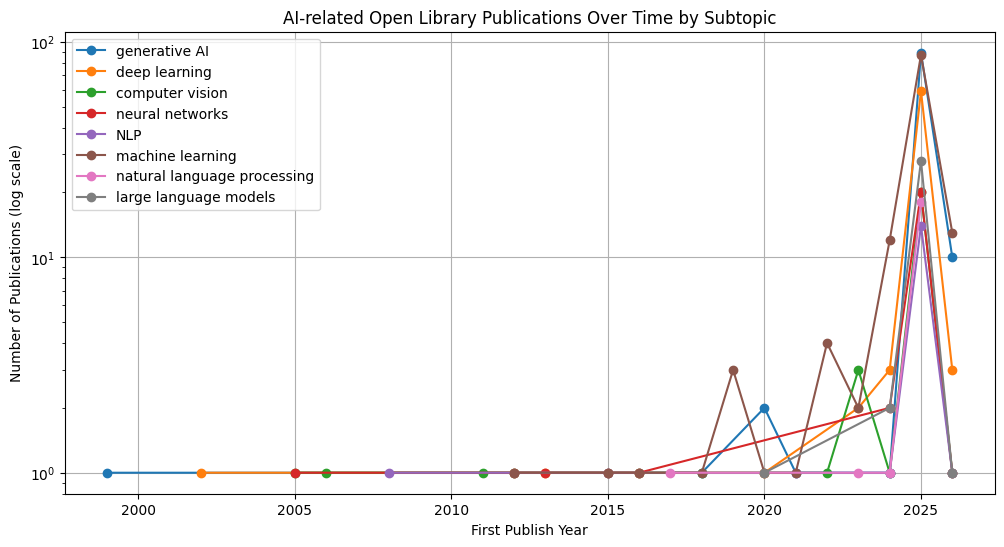

In [37]:
#if not numeric, convert publish year to numeric
df_cleaned["first_publish_year"] = pd.to_numeric(
    df_cleaned["first_publish_year"], errors="coerce"
)

# Remove the broad "artificial intelligence" search topic so it does not dominate the visualization
# We know the growth is there, so it's okay to remove it from the initial visualization
df_subtopics = df_cleaned[
    df_cleaned["search_topic"] != "artificial intelligence"
].copy()

df_years = df_subtopics[
    (df_subtopics["first_publish_year"].notna()) &
    (df_subtopics["first_publish_year"] >= 1950) &
    (df_subtopics["first_publish_year"] <= 2026)
].copy()

# Count books by year and search topic
topic_year_counts = (
    df_years
    .groupby(["first_publish_year", "search_topic"])
    .size()
    .reset_index(name="publication_count")
)

plt.figure(figsize=(12, 6))

for topic in topic_year_counts["search_topic"].unique():
    topic_data = topic_year_counts[
        topic_year_counts["search_topic"] == topic
    ]
    plt.plot(
        topic_data["first_publish_year"],
        topic_data["publication_count"],
        marker="o",
        label=topic
    )
#log scale to see the growth better
plt.yscale("log")
plt.title("AI-related Open Library Publications Over Time by Subtopic")
plt.xlabel("First Publish Year")
plt.ylabel("Number of Publications (log scale)")
plt.legend()
plt.grid(True)
plt.show()

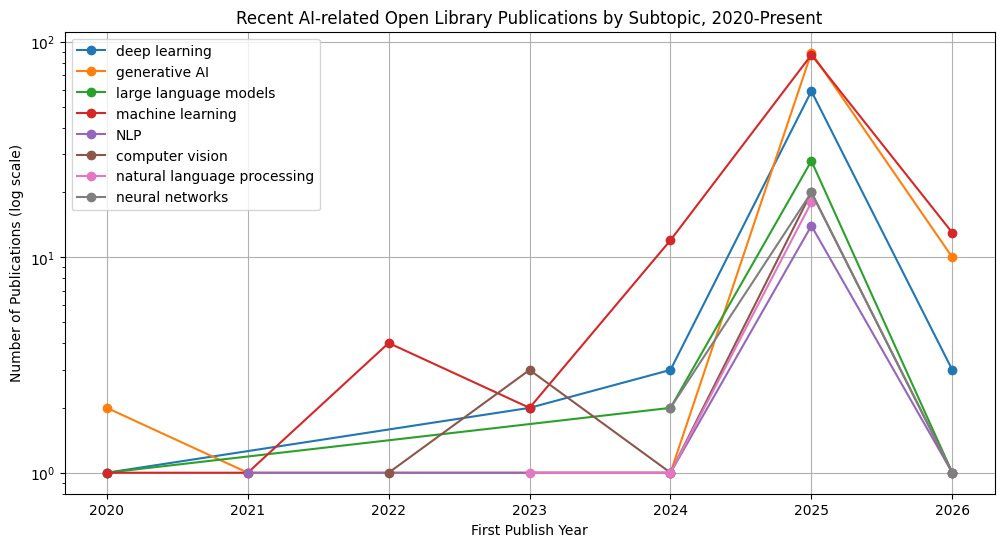

In [ ]:
# Keep only recent 6 years
recent_topic_year_counts = topic_year_counts[
    topic_year_counts["first_publish_year"] >= 2020
]

plt.figure(figsize=(12, 6))

for topic in recent_topic_year_counts["search_topic"].unique():
    topic_data = recent_topic_year_counts[
        recent_topic_year_counts["search_topic"] == topic
    ]
    plt.plot(
        topic_data["first_publish_year"],
        topic_data["publication_count"],
        marker="o",
        label=topic
    )
#log scale to see the growth better
plt.yscale("log")
plt.title("Recent AI-related Open Library Publications by Subtopic, 2020-Present")
plt.xlabel("First Publish Year")
plt.ylabel("Number of Publications (log scale)")
plt.legend()
plt.grid(True)
plt.show()

### AI-related publications over time (Open Library)

The number of AI-related publications in Open Library stays **relatively low before 2020**, with only **scattered** activity across subtopics. After that, the dataset shows a **clear rise** in recent years, especially around **2024** and **2025**.

**Machine learning** and **generative AI** show the **strongest growth**, each peaking in **2025**. **Deep learning** also rises sharply. **Large language models**, **neural networks**, **NLP**, **computer vision**, and **natural language processing** show **smaller but visible** gains.

That pattern suggests recent publishing is **more concentrated** around **newer, high-visibility** areas like **generative AI**, while **machine learning** and **deep learning** remain **heavily represented**.

Since it is only the first quarter of 2026, we do not get the full picture of publications of the year.

   language  count
0       eng    919
1       ita      9
2       ger      7
3       fre      5
4       spa      4
5       lat      2
6       chi      2
7       tur      1
8       hun      1
9       per      1
10      ukr      1
11      rus      1
12      hin      1
13      heb      1
14      grc      1


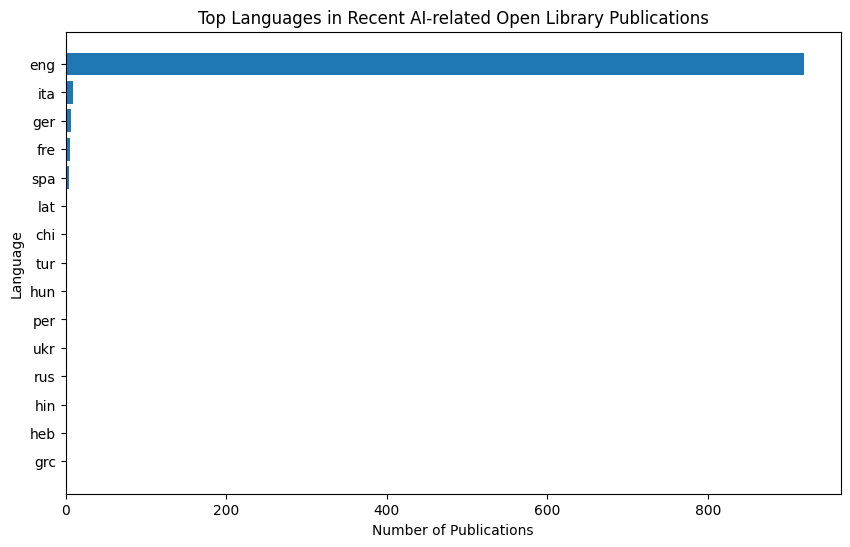

In [ ]:
# Split languages into separate rows
language_counts = (
    df_cleaned
    .dropna(subset=["languages"])
    .assign(languages=df_cleaned["languages"].str.split("; "))
    .explode("languages")
)

# Count language occurrences
language_counts = (
    language_counts["languages"]
    .value_counts()
    .head(15)
    .reset_index()
)

language_counts.columns = ["language", "count"]

print(language_counts)

plt.figure(figsize=(10, 6))
plt.barh(language_counts["language"], language_counts["count"])
plt.xlabel("Number of Publications")
plt.ylabel("Language")
plt.title("Top Languages in Recent AI-related Open Library Publications")
plt.gca().invert_yaxis()
plt.show()

Language distribution (recent AI-related books)
Publications are strongly skewed toward English (eng), at roughly 920 titles—far above every other language in the chart.

The next-largest codes (Italian, German, French, Spanish) each appear only a handful of times.

Several additional codes (Latin, Chinese, Turkish, Hungarian, Persian, Ukrainian, Russian, Hindi, Hebrew, Ancient Greek) appears only a few times (roughly 1–2 or barely visible bars), which is expected when the sample is dominated by one language and the rest are rare in this slice of Open Library metadata.